In [1]:
# ============================================================
# EDA ANALYSIS - STEP 1
# Load cleaned datasets
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Project data path
DATA_PATH = "../data/processed"

# Load datasets
fund_master = pd.read_csv(
    f"{DATA_PATH}/01_fund_master_cleaned.csv"
)

nav_history = pd.read_csv(
    f"{DATA_PATH}/02_nav_history_cleaned.csv"
)

aum_by_fund_house = pd.read_csv(
    f"{DATA_PATH}/03_aum_by_fund_house_cleaned.csv"
)

monthly_sip = pd.read_csv(
    f"{DATA_PATH}/04_monthly_sip_inflows_cleaned.csv"
)

category_inflows = pd.read_csv(
    f"{DATA_PATH}/05_category_inflows_cleaned.csv"
)

folio_count = pd.read_csv(
    f"{DATA_PATH}/06_industry_folio_count_cleaned.csv"
)

scheme_performance = pd.read_csv(
    f"{DATA_PATH}/07_scheme_performance_cleaned.csv"
)

investor_transactions = pd.read_csv(
    f"{DATA_PATH}/08_investor_transactions_cleaned.csv"
)

portfolio_holdings = pd.read_csv(
    f"{DATA_PATH}/09_portfolio_holdings_cleaned.csv"
)

benchmark_indices = pd.read_csv(
    f"{DATA_PATH}/10_benchmark_indices_cleaned.csv"
)

print("All datasets loaded successfully!")

print("\nDataset sizes:")
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("AUM:", aum_by_fund_house.shape)
print("Monthly SIP:", monthly_sip.shape)
print("Category Inflows:", category_inflows.shape)
print("Folio Count:", folio_count.shape)
print("Scheme Performance:", scheme_performance.shape)
print("Investor Transactions:", investor_transactions.shape)
print("Portfolio Holdings:", portfolio_holdings.shape)
print("Benchmark:", benchmark_indices.shape)

All datasets loaded successfully!

Dataset sizes:
Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
Monthly SIP: (48, 6)
Category Inflows: (144, 3)
Folio Count: (21, 6)
Scheme Performance: (40, 19)
Investor Transactions: (32778, 13)
Portfolio Holdings: (322, 8)
Benchmark: (8050, 3)


In [2]:
print(monthly_sip.columns)
print(monthly_sip.head())

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


In [4]:
fig.write_image("sip_inflow_timeseries.png")

print("Saved: sip_inflow_timeseries.png")

NameError: name 'fig' is not defined

In [ ]:
# ============================================================
# STEP 2 - NAV TREND ANALYSIS
# Daily NAV for all 40 schemes
# ============================================================

# Convert date to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Check date range
print("NAV date range:")
print(nav_history["date"].min(), "to", nav_history["date"].max())

print("\nNumber of schemes:", nav_history["amfi_code"].nunique())

# Add scheme names
nav_with_names = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Plot all 40 schemes
fig = px.line(
    nav_with_names,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend - All 40 Mutual Fund Schemes",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Fund"
    }
)

fig.update_layout(
    height=700,
    legend_title="Mutual Fund"
)

fig.show()

NAV date range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00

Number of schemes: 40


In [ ]:
# ============================================================
# STEP 2B - HIGHLIGHT 2023 BULL RUN & 2024 CORRECTION
# ============================================================

fig = px.line(
    nav_with_names,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend - 2022 to 2026"
)

# Highlight 2023 bull-run period
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 correction period
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.08,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    height=700,
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Mutual Fund"
)

fig.show()

In [ ]:
# Save NAV trend chart as HTML
fig.write_html("nav_trend_all_40_funds.html")

print("Saved: nav_trend_all_40_funds.html")

Saved: nav_trend_all_40_funds.html


In [ ]:
# ============================================================
# STEP 3A - CHECK AUM DATA
# ============================================================

print("AUM columns:")
print(aum_by_fund_house.columns.tolist())

print("\nFirst 10 rows:")
display(aum_by_fund_house.head(10))

AUM columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

First 10 rows:


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168
5,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
6,2022-03-31,Axis Mutual Fund,2.50,250000,95
7,2022-03-31,UTI Mutual Fund,2.30,230000,142
8,2022-03-31,Mirae Asset MF,1.05,105000,56
9,2022-03-31,DSP Mutual Fund,1.10,110000,88


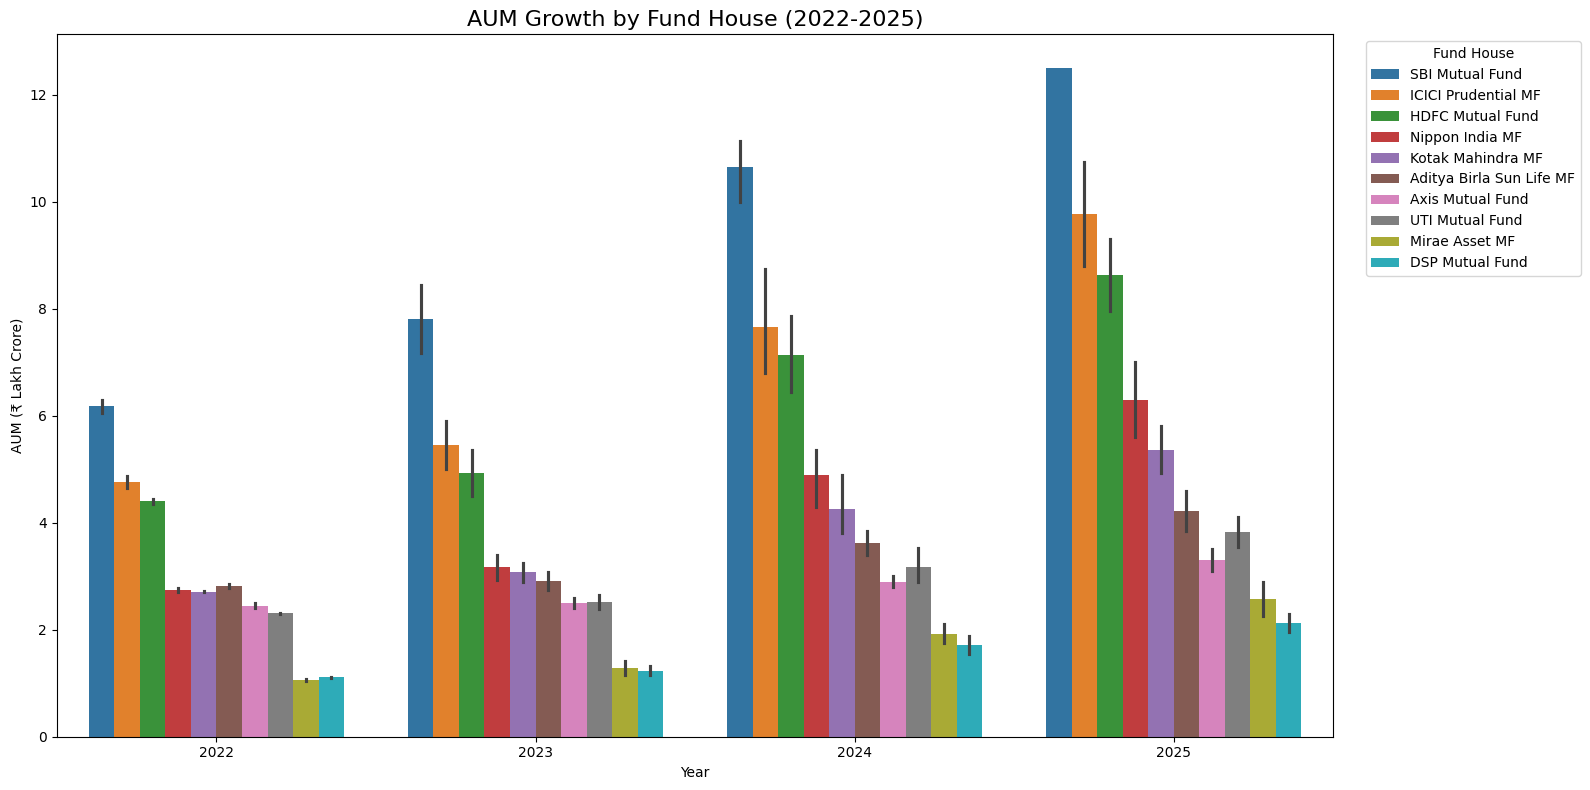

In [ ]:
# ============================================================
# STEP 3B - AUM GROWTH BY FUND HOUSE
# 2022-2025
# ============================================================

# Convert date to datetime
aum_by_fund_house["date"] = pd.to_datetime(aum_by_fund_house["date"])

# Extract year
aum_by_fund_house["year"] = aum_by_fund_house["date"].dt.year

# Keep 2022-2025
aum_chart_data = aum_by_fund_house[
    aum_by_fund_house["year"].between(2022, 2025)
].copy()

# Create grouped bar chart
plt.figure(figsize=(16, 8))

sns.barplot(
    data=aum_chart_data,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 3C - HIGHLIGHT SBI DOMINANCE & SAVE CHART
# ============================================================

# Get SBI's 2025 AUM
sbi_2025 = aum_chart_data[
    (aum_chart_data["fund_house"] == "SBI Mutual Fund") &
    (aum_chart_data["year"] == 2025)
]

if not sbi_2025.empty:
    sbi_value = sbi_2025["aum_lakh_crore"].iloc[0]
    print(f"SBI Mutual Fund 2025 AUM: ₹{sbi_value:.2f} Lakh Crore")

# Save the chart
plt.savefig(
    "aum_growth_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

print("Saved: aum_growth_by_fund_house.png")

SBI Mutual Fund 2025 AUM: ₹12.50 Lakh Crore
Saved: aum_growth_by_fund_house.png


<Figure size 640x480 with 0 Axes>

Saved correctly: aum_growth_by_fund_house.png


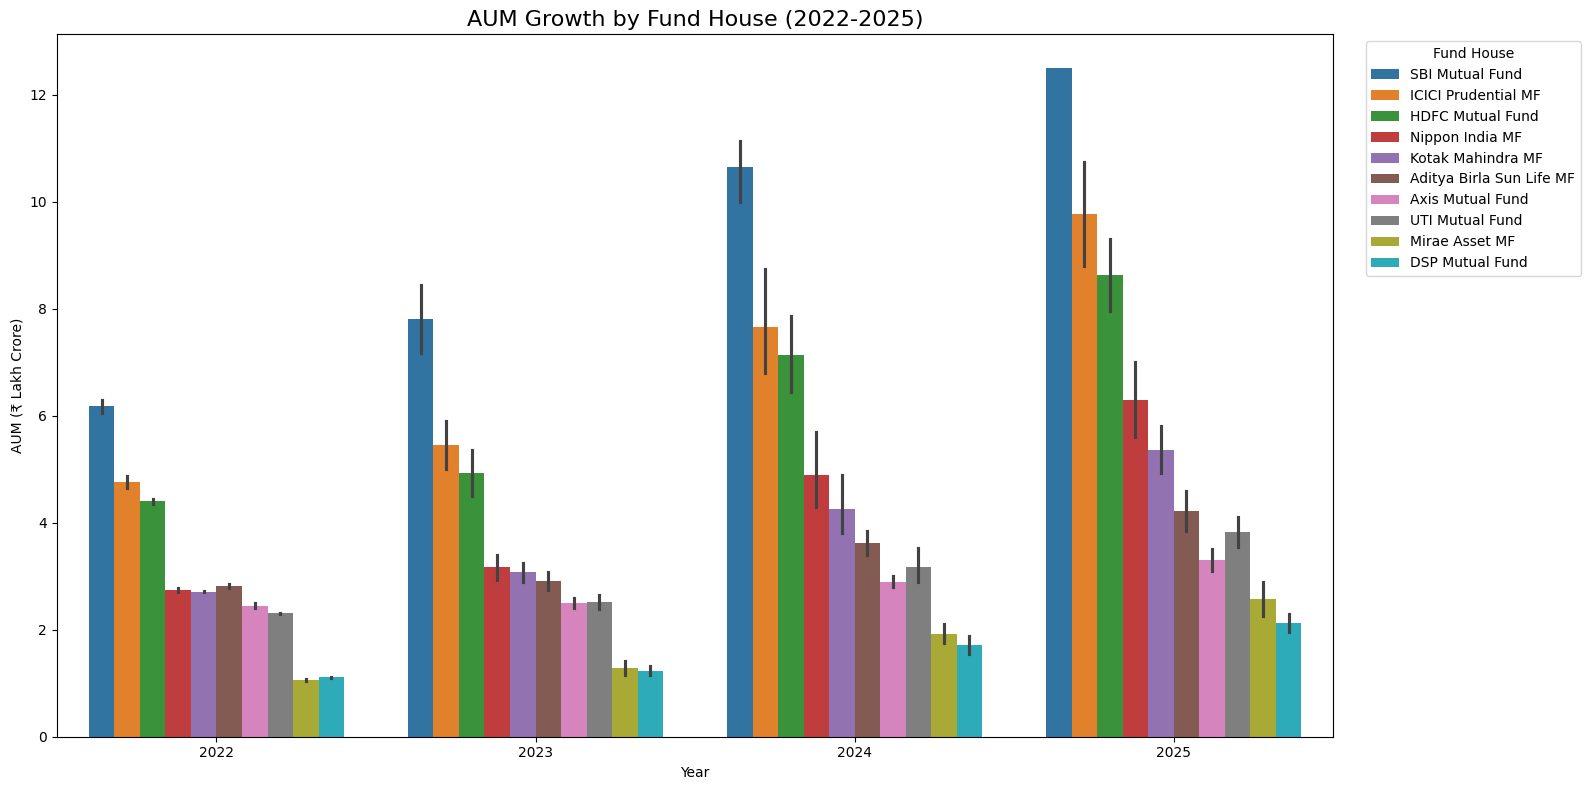

In [ ]:
# ============================================================
# STEP 3D - RECREATE AND SAVE AUM CHART CORRECTLY
# ============================================================

plt.figure(figsize=(16, 8))

sns.barplot(
    data=aum_chart_data,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Save BEFORE showing
plt.savefig(
    "aum_growth_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

print("Saved correctly: aum_growth_by_fund_house.png")

plt.show()

In [ ]:
print(sip_df.columns)
print(sip_df.head())

NameError: name 'sip_df' is not defined

In [5]:
# ============================================================
# 3. SIP INFLOW TIME-SERIES
# ============================================================

monthly_sip["month"] = pd.to_datetime(monthly_sip["month"])

fig = px.line(
    monthly_sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Find the highest SIP inflow
peak_row = monthly_sip.loc[
    monthly_sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(
    x=peak_row["month"],
    y=peak_row["sip_inflow_crore"],
    text=f"Peak: ₹{peak_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True
)

fig.show()


In [6]:
# Save SIP inflow chart as PNG
fig.write_image("sip_inflow_timeseries.png")

print("Saved: sip_inflow_timeseries.png")

Saved: sip_inflow_timeseries.png


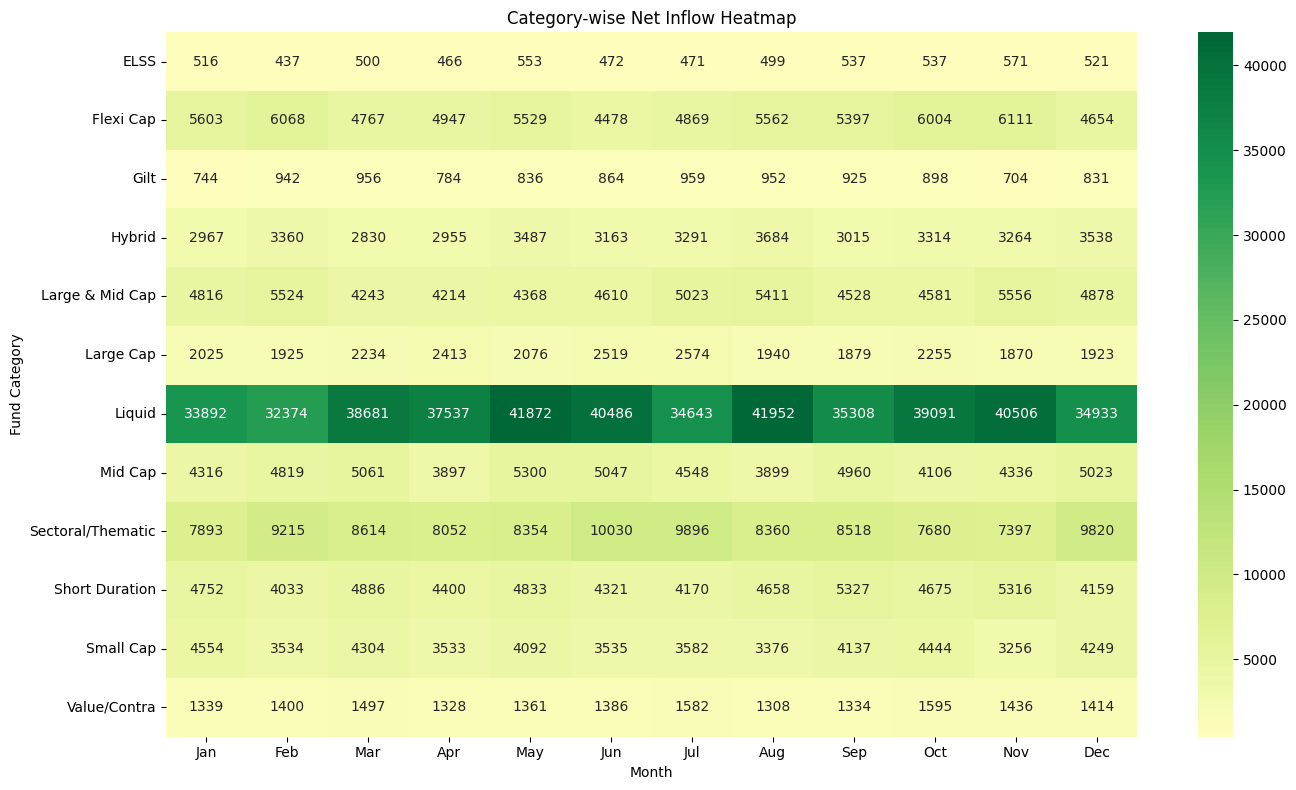

Saved: category_inflow_heatmap.png


In [7]:
# ============================================================
# 4. CATEGORY INFLOW HEATMAP
# ============================================================

# Make sure date/month is in datetime format
category_inflows["month"] = pd.to_datetime(category_inflows["month"])

# Create month names for X-axis
category_inflows["month_name"] = category_inflows["month"].dt.strftime("%b")

# Pivot table: categories × months
heatmap_data = category_inflows.pivot_table(
    index="category",
    columns="month_name",
    values="net_inflow_crore",
    aggfunc="sum"
)

# Keep months in calendar order
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

heatmap_data = heatmap_data.reindex(
    columns=[m for m in month_order if m in heatmap_data.columns]
)

# Plot heatmap
plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.tight_layout()

plt.savefig(
    "category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: category_inflow_heatmap.png")

In [8]:
# ============================================================
# 5. INVESTOR DEMOGRAPHICS
# ============================================================

print("Investor transaction columns:")
print(investor_transactions.columns)

print("\nFirst 5 rows:")
display(investor_transactions.head())

Investor transaction columns:
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

First 5 rows:


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


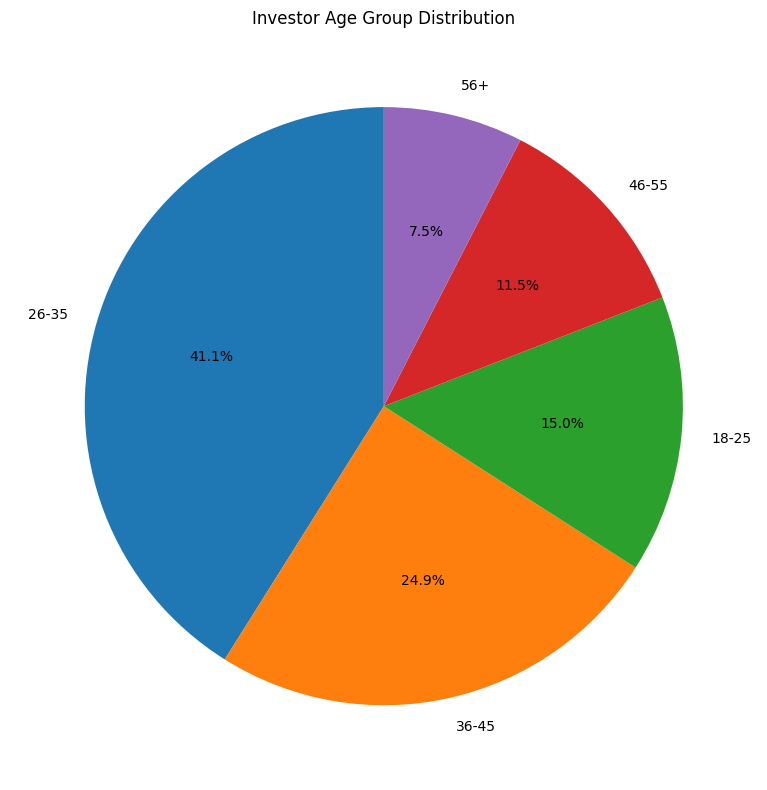

Saved: investor_age_distribution.png


In [9]:
# ============================================================
# 5A. AGE GROUP DISTRIBUTION - PIE CHART
# ============================================================

age_counts = investor_transactions["age_group"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.tight_layout()

plt.savefig(
    "investor_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: investor_age_distribution.png")

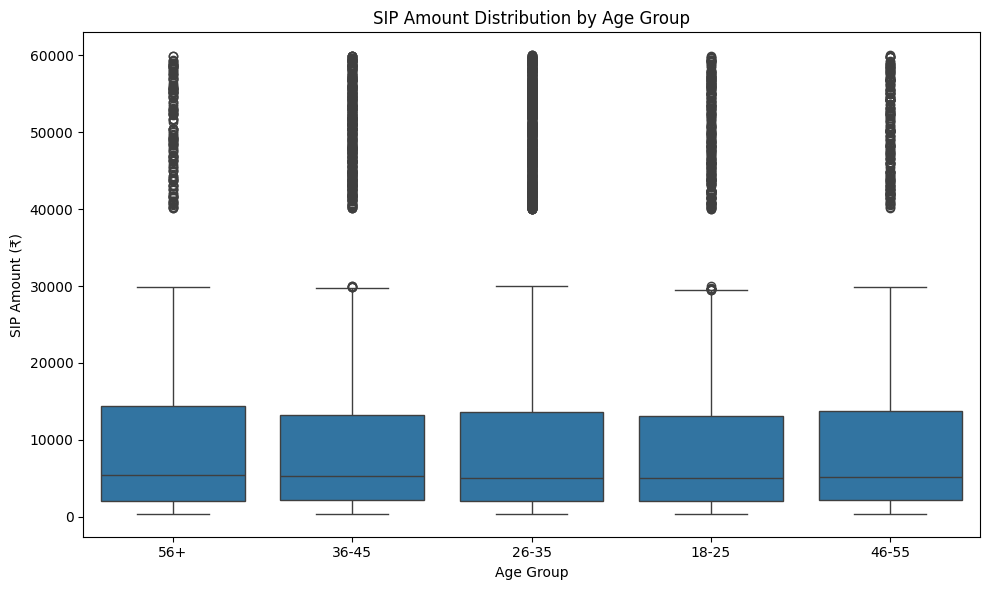

Saved: sip_amount_by_age_group.png


In [10]:
# ============================================================
# 5B. SIP AMOUNT BY AGE GROUP - BOX PLOT
# ============================================================

# Keep only SIP transactions
sip_transactions = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

# Remove missing age groups and amounts
sip_transactions = sip_transactions.dropna(
    subset=["age_group", "amount_inr"]
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.tight_layout()

plt.savefig(
    "sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: sip_amount_by_age_group.png")

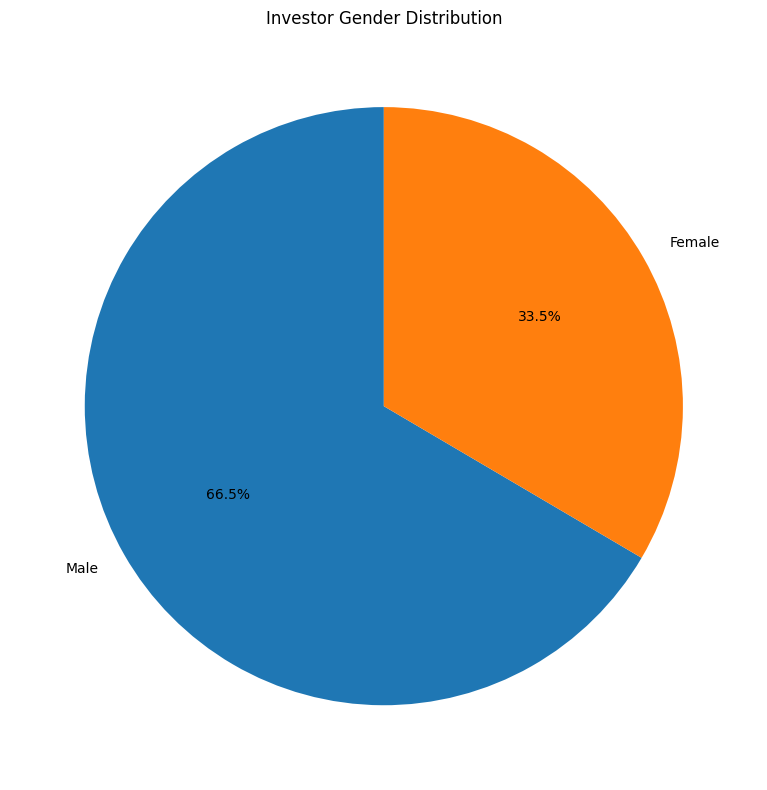

Saved: investor_gender_split.png


In [11]:
# ============================================================
# 5C. GENDER SPLIT - PIE CHART
# ============================================================

gender_counts = investor_transactions["gender"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")
plt.tight_layout()

plt.savefig(
    "investor_gender_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: investor_gender_split.png")

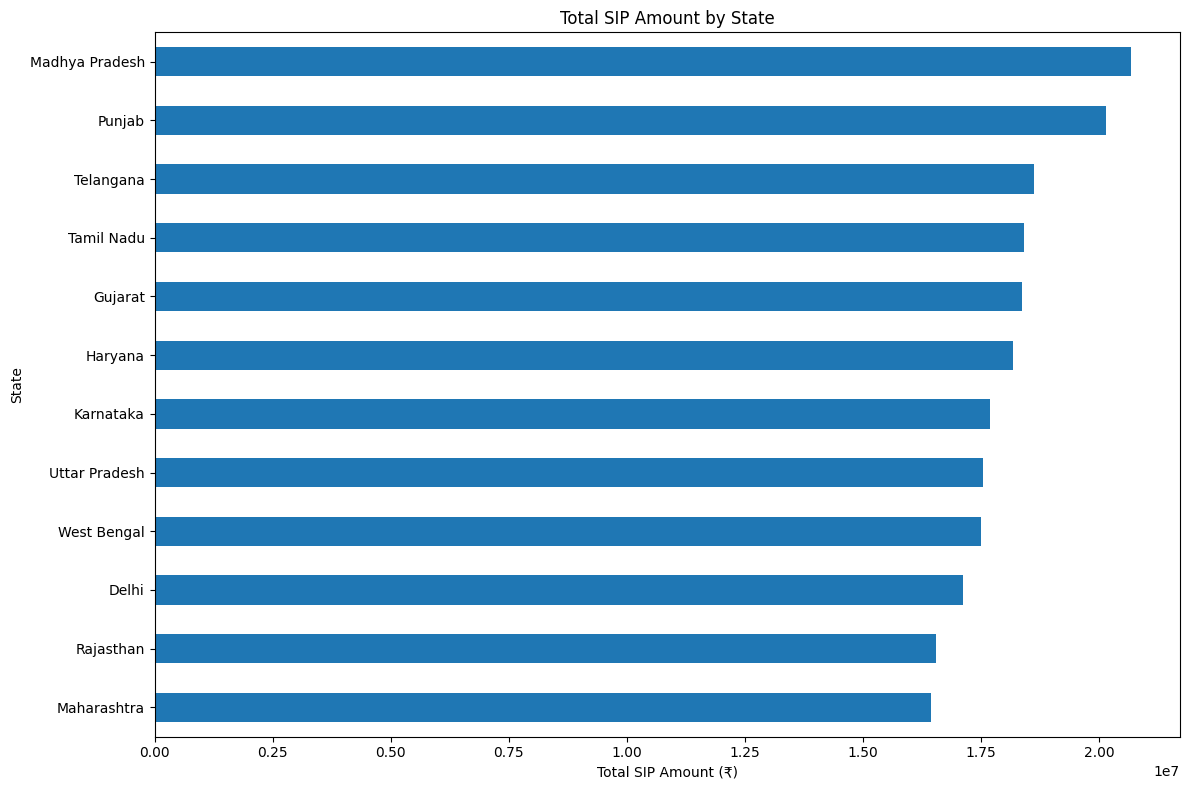

Saved: sip_amount_by_state.png


In [12]:
# ============================================================
# 6A. SIP AMOUNT BY STATE - HORIZONTAL BAR CHART
# ============================================================

# Keep only SIP transactions
state_sip = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

# Calculate total SIP amount by state
state_sip_amount = (
    state_sip
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 8))

state_sip_amount.plot(
    kind="barh"
)

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")
plt.tight_layout()

plt.savefig(
    "sip_amount_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: sip_amount_by_state.png")

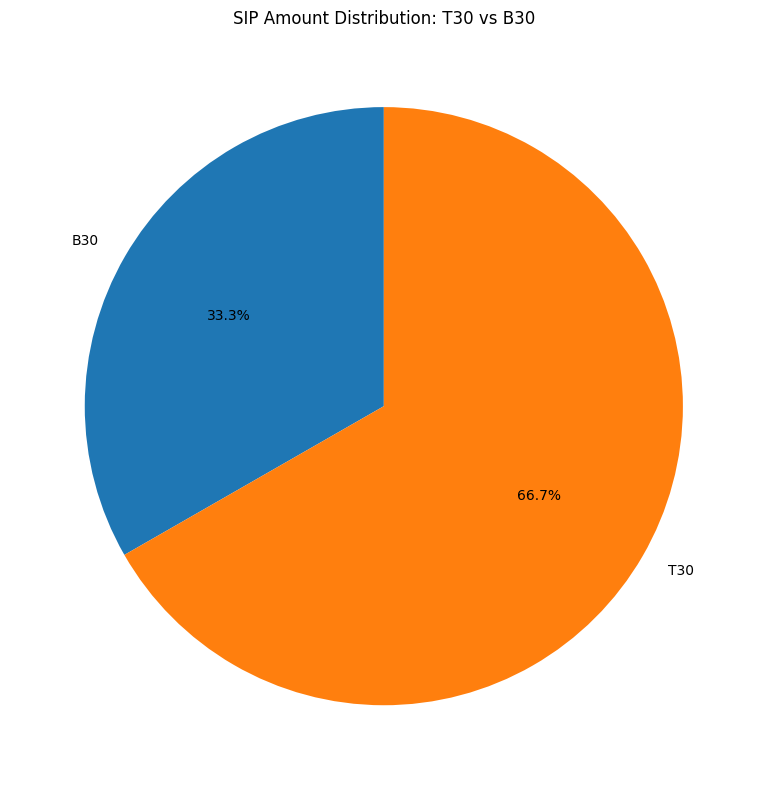

Saved: t30_vs_b30_sip.png


In [13]:
# ============================================================
# 6B. T30 vs B30 CITY TIER - PIE CHART
# ============================================================

# Keep only SIP transactions
tier_sip = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

# Calculate total SIP amount by city tier
tier_sip_amount = (
    tier_sip
    .groupby("city_tier")["amount_inr"]
    .sum()
)

plt.figure(figsize=(8, 8))

plt.pie(
    tier_sip_amount.values,
    labels=tier_sip_amount.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("SIP Amount Distribution: T30 vs B30")
plt.tight_layout()

plt.savefig(
    "t30_vs_b30_sip.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: t30_vs_b30_sip.png")

In [14]:
# ============================================================
# 7. FOLIO COUNT GROWTH
# ============================================================

# Convert date column to datetime
folio_count["date"] = pd.to_datetime(folio_count["date"])

# Sort by date
folio_count = folio_count.sort_values("date")

# Display the columns first
print(folio_count.columns)
print(folio_count.head())

KeyError: 'date'

In [15]:
print(folio_count.columns)
print(folio_count.head())

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


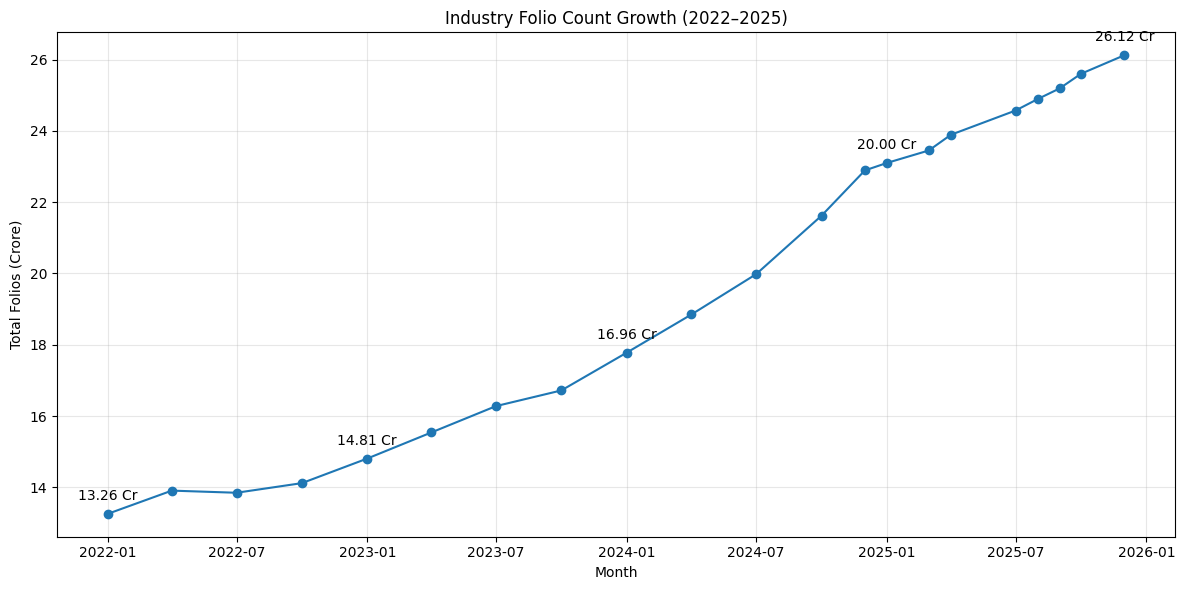

Saved: folio_count_growth.png
Starting folios: 13.26 Cr
Ending folios: 26.12 Cr


In [16]:
# ============================================================
# 7. FOLIO COUNT GROWTH
# ============================================================

# Convert month to datetime
folio_count["month"] = pd.to_datetime(folio_count["month"])

# Sort by month
folio_count = folio_count.sort_values("month")

# Create the line chart
plt.figure(figsize=(12, 6))

plt.plot(
    folio_count["month"],
    folio_count["total_folios_crore"],
    marker="o"
)

# Mark important milestones
milestones = {
    "2022-01": "13.26 Cr",
    "2023-01": "14.81 Cr",
    "2024-01": "16.96 Cr",
    "2025-01": "20.00 Cr",
    "2025-12": "26.12 Cr"
}

for month, label in milestones.items():
    row = folio_count[
        folio_count["month"] == pd.to_datetime(month)
    ]

    if not row.empty:
        x = row["month"].iloc[0]
        y = row["total_folios_crore"].iloc[0]

        plt.annotate(
            label,
            (x, y),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center"
        )

plt.title("Industry Folio Count Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "folio_count_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: folio_count_growth.png")
print(
    "Starting folios:",
    folio_count["total_folios_crore"].iloc[0],
    "Cr"
)
print(
    "Ending folios:",
    folio_count["total_folios_crore"].iloc[-1],
    "Cr"
)

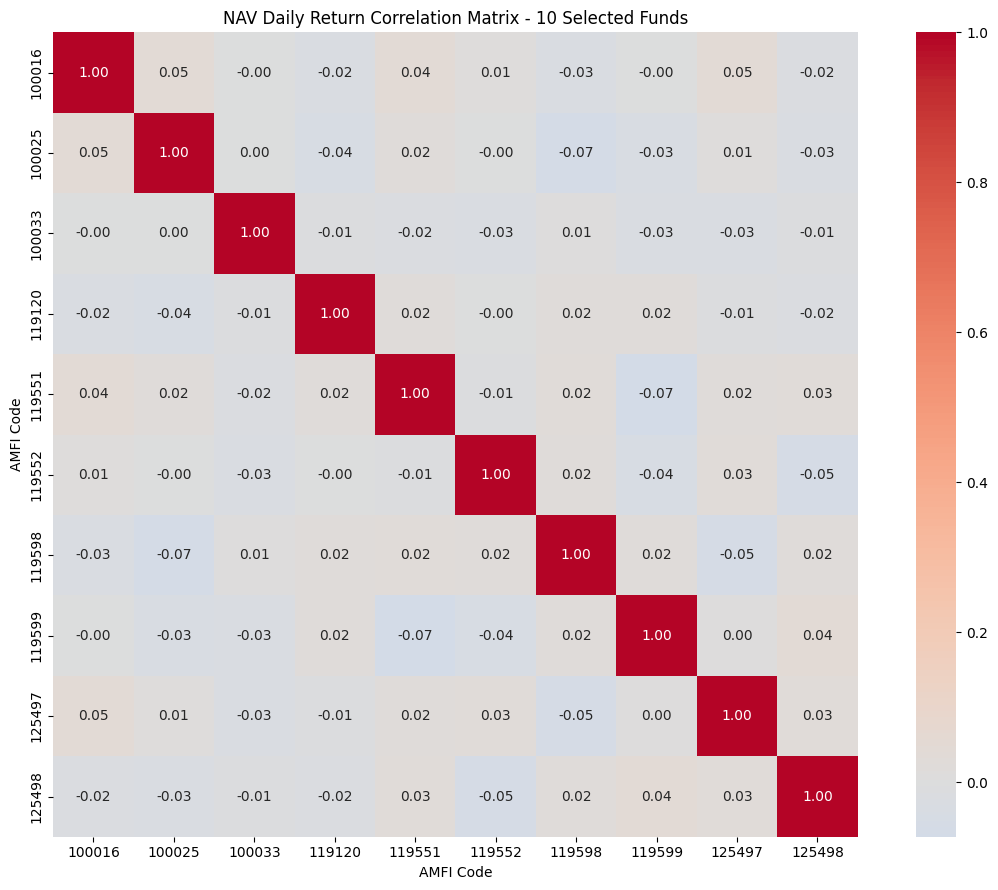

Saved: nav_return_correlation_matrix.png

Correlation Matrix:


amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,-0.022521,0.040858,0.013663,-0.030296,-0.000007,0.047139,-0.016089
100025,0.045567,1.000000,0.002150,-0.040884,0.017017,-0.002803,-0.065019,-0.034061,0.011326,-0.025505
100033,-0.000006,0.002150,1.000000,-0.007166,-0.015559,-0.027471,0.006659,-0.028323,-0.025137,-0.011916
119120,-0.022521,-0.040884,-0.007166,1.000000,0.021601,-0.004003,0.018423,0.017795,-0.010542,-0.016315
119551,0.040858,0.017017,-0.015559,0.021601,1.000000,-0.006819,0.024409,-0.072559,0.016469,0.030454
119552,0.013663,-0.002803,-0.027471,-0.004003,-0.006819,1.000000,0.020754,-0.042415,0.027796,-0.052299
119598,-0.030296,-0.065019,0.006659,0.018423,0.024409,0.020754,1.000000,0.018187,-0.053278,0.018443
119599,-0.000007,-0.034061,-0.028323,0.017795,-0.072559,-0.042415,0.018187,1.000000,0.003347,0.041927
125497,0.047139,0.011326,-0.025137,-0.010542,0.016469,0.027796,-0.053278,0.003347,1.000000,0.027394


In [17]:
# ============================================================
# 8. NAV RETURN CORRELATION MATRIX - 10 SELECTED FUNDS
# ============================================================

# Convert date to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Select 10 funds
selected_funds = fund_master["amfi_code"].head(10).tolist()

# Filter NAV data for selected funds
selected_nav = nav_history[
    nav_history["amfi_code"].isin(selected_funds)
].copy()

# Sort by fund and date
selected_nav = selected_nav.sort_values(
    ["amfi_code", "date"]
)

# Calculate daily returns
selected_nav["daily_return"] = (
    selected_nav.groupby("amfi_code")["nav"]
    .pct_change()
)

# Convert to wide format
returns_matrix = selected_nav.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

# Calculate correlation matrix
correlation_matrix = returns_matrix.corr()

# Plot heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("NAV Daily Return Correlation Matrix - 10 Selected Funds")
plt.xlabel("AMFI Code")
plt.ylabel("AMFI Code")
plt.tight_layout()

plt.savefig(
    "nav_return_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: nav_return_correlation_matrix.png")
print("\nCorrelation Matrix:")
display(correlation_matrix)

In [18]:
# ============================================================
# 9. SECTOR ALLOCATION - CHECK COLUMNS
# ============================================================

print(portfolio_holdings.columns)
print(portfolio_holdings.head())

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


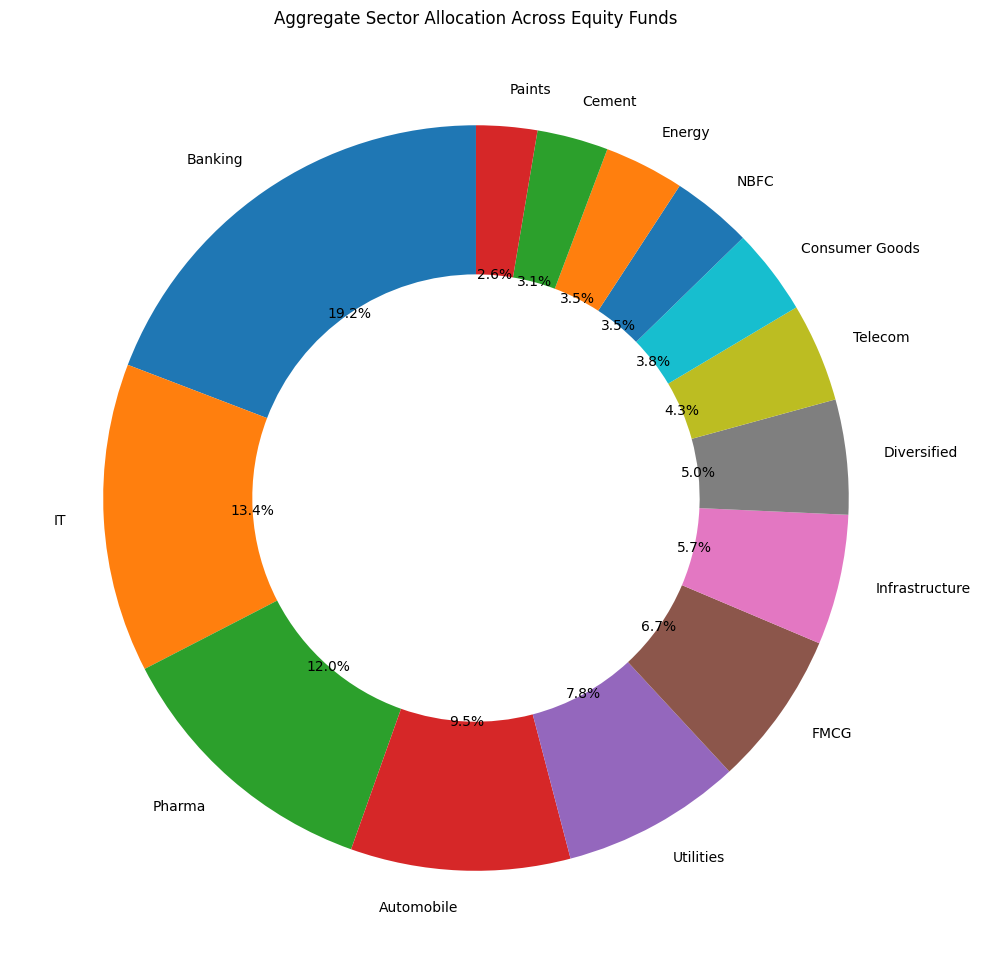

Saved: sector_allocation_donut.png

Sector Allocation:
sector
Banking           19.18
IT                13.40
Pharma            11.98
Automobile         9.52
Utilities          7.81
FMCG               6.74
Infrastructure     5.65
Diversified        4.98
Telecom            4.28
Consumer Goods     3.75
NBFC               3.50
Energy             3.47
Cement             3.09
Paints             2.64
Name: weight_pct, dtype: float64


In [19]:
# ============================================================
# 9. SECTOR ALLOCATION - DONUT CHART
# ============================================================

# Aggregate portfolio weights by sector
sector_allocation = (
    portfolio_holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# Convert to percentage of total portfolio weight
sector_allocation_pct = (
    sector_allocation / sector_allocation.sum() * 100
)

# Create donut chart
plt.figure(figsize=(10, 10))

plt.pie(
    sector_allocation_pct.values,
    labels=sector_allocation_pct.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Aggregate Sector Allocation Across Equity Funds")

plt.tight_layout()

plt.savefig(
    "sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: sector_allocation_donut.png")
print("\nSector Allocation:")
print(sector_allocation_pct.round(2))

# Key EDA Findings

1. **NAV Trend:** The daily NAV analysis shows that mutual fund schemes experienced varying growth patterns from 2022 to 2026, with noticeable market movement during the highlighted 2023 bull run and 2024 correction period.

2. **AUM Growth:** SBI Mutual Fund remained the largest fund house in the dataset, with AUM reaching approximately ₹12.50 Lakh Crore in 2025.

3. **SIP Inflows:** Monthly SIP contributions showed an overall increasing trend between 2022 and 2025, reaching an all-time high of ₹31,002 Crore in December 2025.

4. **Category Inflows:** Net inflows varied substantially across fund categories and months, indicating changing investor preferences over the analysis period.

5. **Investor Age Distribution:** The investor base is distributed across multiple age groups, showing participation from both younger and older investors in mutual fund investments.

6. **SIP Amount by Age:** SIP contribution amounts differ across age groups, indicating differences in investment capacity and preferences among investors.

7. **Geographic Distribution:** Maharashtra and other major states contribute significantly to mutual fund transaction activity, while SIP participation is spread across both T30 and B30 cities.

8. **Folio Growth:** Total mutual fund folios increased from 13.26 Crore in January 2022 to 26.12 Crore in December 2025, indicating strong growth in investor participation.

9. **Sector Allocation:** Banking has the highest aggregate portfolio allocation at 19.18%, followed by IT at 13.40% and Pharma at 11.98%, making these major sectors in the selected equity-fund portfolios.

10. **Fund Correlation:** The NAV return correlation analysis shows that selected mutual funds have different levels of co-movement, highlighting diversification opportunities across schemes.

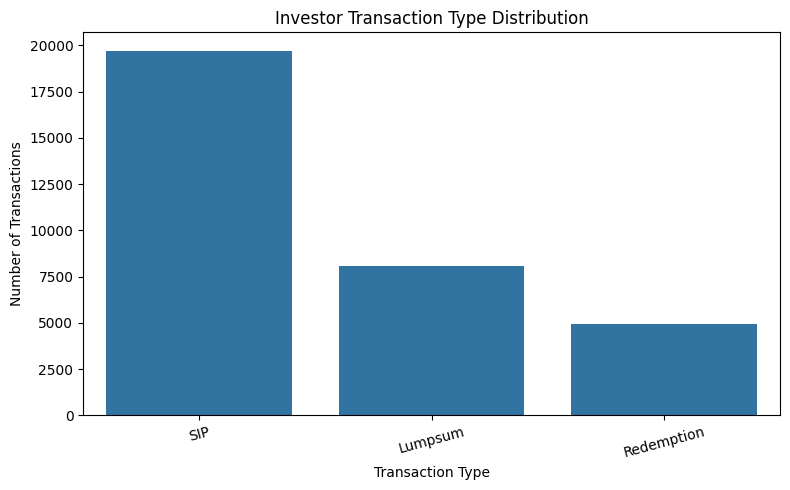

Saved: transaction_type_distribution.png


In [20]:
# ============================================================
# CHART 13 - TRANSACTION TYPE DISTRIBUTION
# ============================================================

transaction_counts = investor_transactions["transaction_type"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=transaction_counts.index,
    y=transaction_counts.values
)

plt.title("Investor Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig("transaction_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: transaction_type_distribution.png")


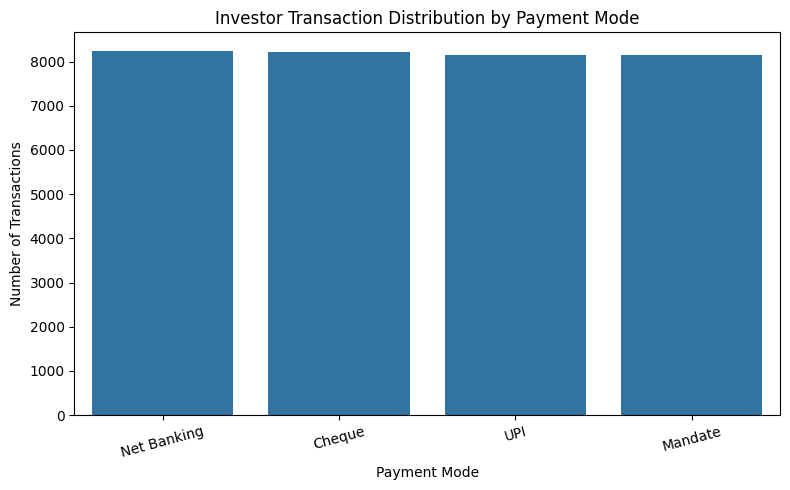

Saved: payment_mode_distribution.png


In [21]:
# ============================================================
# CHART 14 - PAYMENT MODE DISTRIBUTION
# ============================================================

payment_counts = investor_transactions["payment_mode"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

plt.title("Investor Transaction Distribution by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "payment_mode_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: payment_mode_distribution.png")

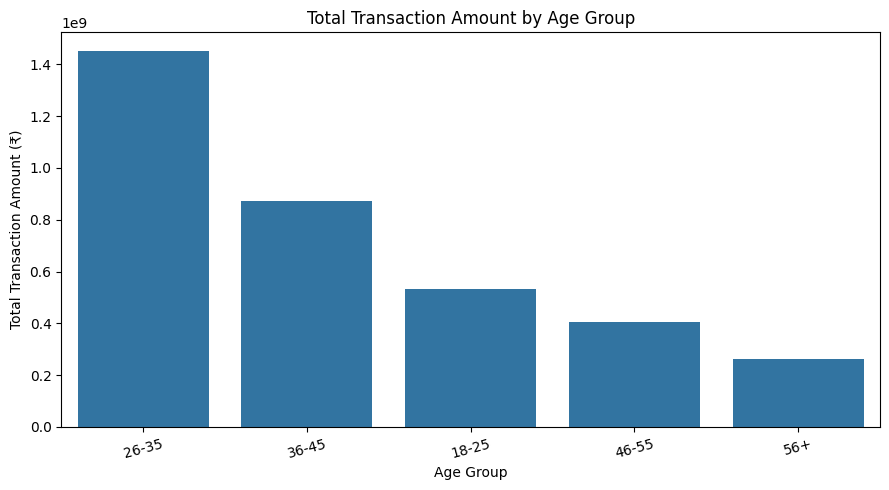

Saved: transaction_amount_by_age_group.png


In [22]:
# ============================================================
# CHART 15 - TRANSACTION AMOUNT BY AGE GROUP
# ============================================================

age_amount = (
    investor_transactions
    .groupby("age_group")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_amount.index,
    y=age_amount.values
)

plt.title("Total Transaction Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Transaction Amount (₹)")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "transaction_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: transaction_amount_by_age_group.png")